Thiết bị sử dụng: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 25.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 584kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.41MB/s]


Kích thước tập train: 60000
Kích thước tập test : 10000
Kích thước một ảnh sau tiền xử lý: torch.Size([1, 32, 32])
Nhãn của ảnh mẫu: 5
LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): Tanh()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=120, out_features=84, bias=True)
    (2): Tanh()
    (3): Linear(in_features=84, out_features=10, bias=True)
  )
)
Epoch [1/5] - loss: 0.4034 - accuracy: 0.8853 - val_loss: 0.1690 - val_accuracy: 0.9458
Epoch [2/5] - loss: 0.1191 - accuracy: 0.9640 - val_loss: 0.0968 - val_accuracy: 0.9703
Epoch [3/5] - loss: 0.0775 - accuracy: 0.9761 - val_loss: 0.0861 - val_accuracy: 0.9757
Epoch [4/5] - los

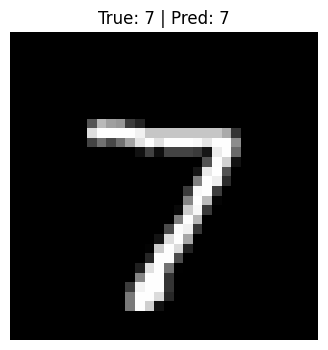

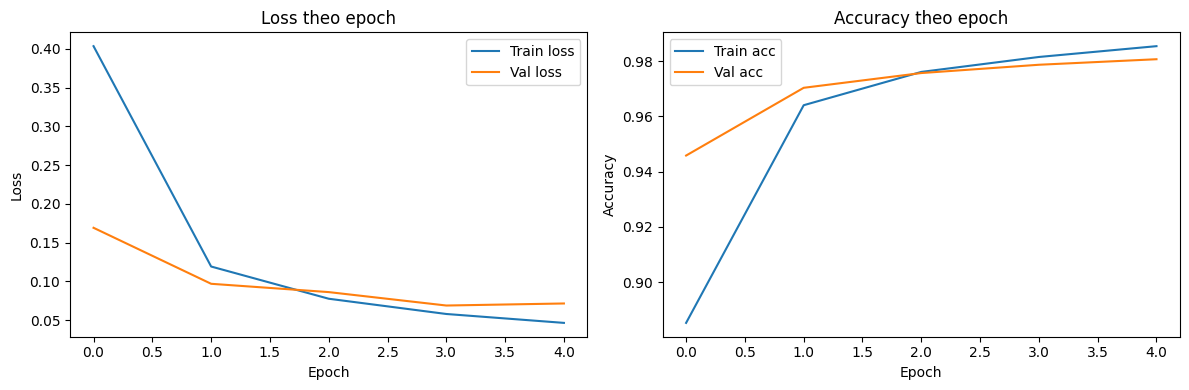

Kiểm tra hoàn tất: dữ liệu, mô hình và dự đoán có định dạng hợp lệ.


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: Xây dựng, huấn luyện và kiểm tra mạng LeNet-5 với MNIST
# Chương/Mục liên quan: Chương 7 - Mạng nơ-ron tích chập cho phân loại ảnh
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa quá trình xây dựng và huấn luyện mạng LeNet-5 cho bài toán phân loại chữ số viết tay.
# - Giúp người học quan sát trực tiếp vai trò của các lớp convolution, pooling và fully-connected.
# - Liên hệ phần code với kiến trúc CNN cổ điển trong giáo trình.

# Sau khi chạy code, người học cần:
# 1. Hiểu được cách dữ liệu ảnh được chuẩn hóa và đưa vào mạng CNN.
# 2. Quan sát được quá trình học thông qua loss và accuracy.
# 3. Biết kiểm tra kết quả dự đoán của mô hình trên ảnh kiểm thử.

# Input:
# - Dữ liệu đầu vào: bộ MNIST có sẵn trong torchvision.datasets
# - Kiểu dữ liệu: ảnh mức xám kích thước 28x28, được pad thành 32x32x1

# Output:
# - Kích thước dữ liệu train/test
# - Kiến trúc mạng LeNet-5
# - Độ chính xác và hàm mất mát trên tập test
# - Ảnh kiểm thử cùng nhãn thật và nhãn dự đoán
# - Đường học loss và accuracy theo epoch

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa kiến trúc LeNet-5;
# - Các bước xử lý tương ứng với pipeline huấn luyện CNN;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Thiết bị sử dụng:", device)

# Transform:
# - ToTensor(): chuyển ảnh PIL 28x28 về tensor dạng (1, 28, 28), giá trị [0, 1]
# - Pad(2): pad ảnh từ 28x28 thành 32x32 để phù hợp với LeNet-5 gốc
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2)
])

train_full = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Kích thước tập train:", len(train_full))
print("Kích thước tập test :", len(test_dataset))

# Chia tập train thành train/validation theo tỉ lệ 90% / 10%
train_size = int(0.9 * len(train_full))
val_size = len(train_full) - train_size

train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# ============================================================
# 3. HIỂN THỊ VÀ TIỀN XỬ LÝ DỮ LIỆU ĐẦU VÀO
# ============================================================

sample_x, sample_y = train_full[0]

print("Kích thước một ảnh sau tiền xử lý:", sample_x.shape)
print("Nhãn của ảnh mẫu:", sample_y)

# Trong PyTorch, dữ liệu ảnh có dạng:
# (N, C, H, W), tức là batch_size x số_kênh x chiều_cao x chiều_rộng.
# Với MNIST sau khi pad: (N, 1, 32, 32).


# ============================================================
# 4. XỬ LÝ CHÍNH: XÂY DỰNG VÀ HUẤN LUYỆN LENET-5
# ============================================================

# Kiến trúc LeNet-5:
# Input: 32x32x1
# C1: Conv 5x5, 6 feature maps, tanh      -> 28x28x6
# S2: Average Pooling 2x2, stride 2       -> 14x14x6
# C3: Conv 5x5, 16 feature maps, tanh     -> 10x10x16
# S4: Average Pooling 2x2, stride 2       -> 5x5x16
# C5: Conv 5x5, 120 feature maps, tanh    -> 1x1x120
# F6: Dense 84, tanh
# Output: Dense 10

class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5),
            nn.Tanh()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 84),
            nn.Tanh(),

            # LeNet-5 gốc dùng cơ chế phân lớp khác;
            # trong thực hành hiện nay thường dùng softmax hoặc cross-entropy cho phân loại đa lớp.
            # Trong PyTorch, CrossEntropyLoss đã bao gồm log-softmax bên trong,
            # nên lớp cuối chỉ trả về logits, không cần đặt softmax ở đây.
            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = LeNet5().to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

history = {
    "loss": [],
    "accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(epochs):
    # ----------------------------
    # Huấn luyện
    # ----------------------------
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss / train_total
    train_acc = train_correct / train_total

    # ----------------------------
    # Đánh giá trên tập validation
    # ----------------------------
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"- loss: {train_loss:.4f} "
        f"- accuracy: {train_acc:.4f} "
        f"- val_loss: {val_loss:.4f} "
        f"- val_accuracy: {val_acc:.4f}"
    )


# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

test_loss = test_loss / test_total
test_acc = test_correct / test_total

print(f"\nĐộ chính xác trên tập test: {test_acc:.4f}")
print(f"Hàm mất mát trên tập test: {test_loss:.4f}")

idx = 0
sample_image, sample_label = test_dataset[idx]

with torch.no_grad():
    input_image = sample_image.unsqueeze(0).to(device)
    output = model(input_image)

    prob = torch.softmax(output, dim=1)
    pred_class = torch.argmax(prob, dim=1).item()
    pred_prob = torch.max(prob).item()

print(f"\nNhãn thật      : {sample_label}")
print(f"Nhãn dự đoán   : {pred_class}")
print(f"Độ tin cậy     : {pred_prob:.4f}")

plt.figure(figsize=(4, 4))
plt.imshow(sample_image.squeeze(), cmap="gray")
plt.title(f"True: {sample_label} | Pred: {pred_class}")
plt.axis("off")
plt.show()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["loss"], label="Train loss")
plt.plot(history["val_loss"], label="Val loss")
plt.title("Loss theo epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["accuracy"], label="Train acc")
plt.plot(history["val_accuracy"], label="Val acc")
plt.title("Accuracy theo epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

assert sample_image.shape == (1, 32, 32)
assert output.shape == (1, 10)
assert 0 <= pred_class <= 9

print("Kiểm tra hoàn tất: dữ liệu, mô hình và dự đoán có định dạng hợp lệ.")


# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi epochs từ 5 lên 10 để quan sát đường học loss và accuracy.
# 2. Thay đổi batch_size từ 128 sang 64 hoặc 256 để quan sát ảnh hưởng đến quá trình huấn luyện.
# 3. Thay đổi idx để kiểm tra dự đoán trên các ảnh khác nhau trong tập test.

digits_0_noise.png -> dự đoán: 0, độ tin cậy: 0.9989
digits_1_noise.png -> dự đoán: 8, độ tin cậy: 0.9282
digits_2_noise.png -> dự đoán: 2, độ tin cậy: 0.9990
digits_3_noise.png -> dự đoán: 3, độ tin cậy: 0.9998
digits_4_noise.png -> dự đoán: 5, độ tin cậy: 0.9958
digits_5_noise.png -> dự đoán: 6, độ tin cậy: 0.9626
digits_6_noise.png -> dự đoán: 2, độ tin cậy: 0.6309
digits_7_noise.png -> dự đoán: 8, độ tin cậy: 0.9958
digits_8_noise.png -> dự đoán: 8, độ tin cậy: 0.9998
digits_9_noise.png -> dự đoán: 9, độ tin cậy: 0.9582


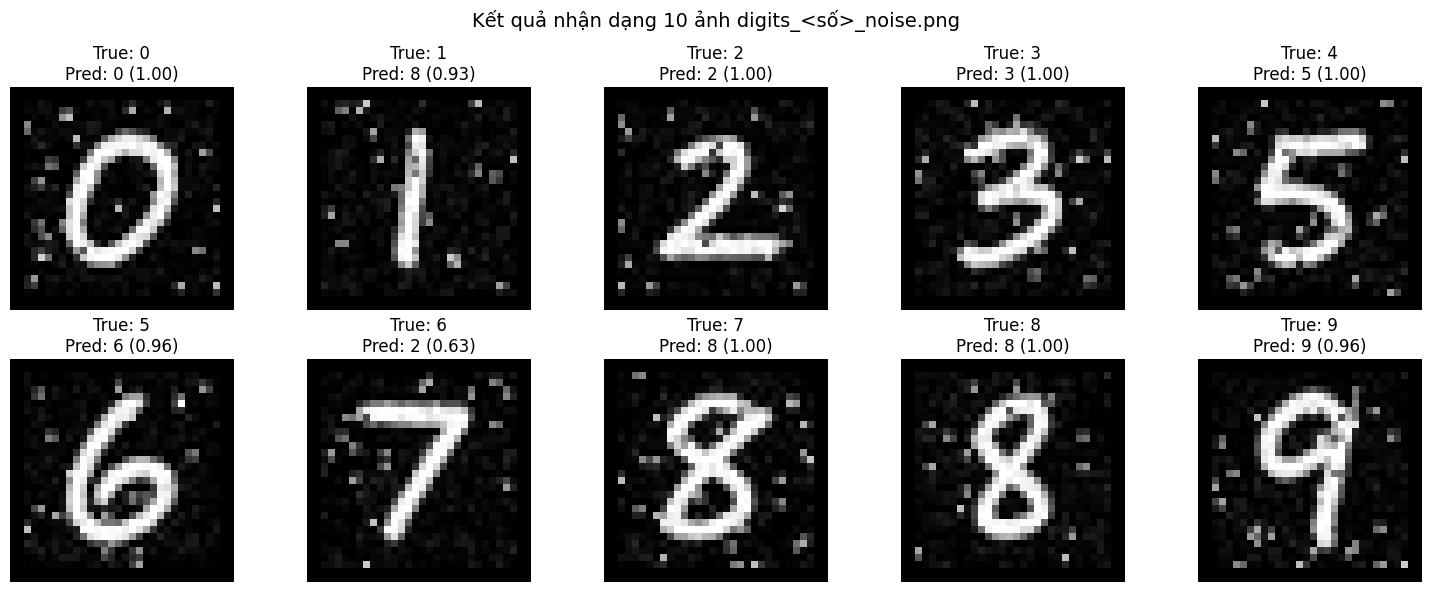


Độ chính xác trên 10 ảnh kiểm tra: 0.5000


In [ ]:
# ============================================================
# 10. Thử nhận dạng 10 ảnh nhiễu digits_0_noise.png ... digits_9_noise.png
# Chú ý:
# - Cần thay base_url cho đúng với thư mục chứa ảnh
# - Ảnh đầu vào sẽ được chuyển về đúng định dạng mà LeNet-5 đã học:
#   grayscale -> resize 28x28 -> normalize -> pad thành 32x32
# ============================================================

from urllib.request import urlopen
from PIL import Image
import io

# Ví dụ:
# base_url = "https://github.com/lthavnu/cv-book/raw/main/images"
# Nếu ảnh nằm trong thư mục con digits thì:
base_url = "https://github.com/lthavnu/cv-book/raw/main/images/digits"

def load_digit_image_from_url(image_url):
    """
    Đọc ảnh từ URL, chuyển về grayscale, resize 28x28,
    chuẩn hóa [0,1], rồi pad thành 32x32x1.
    """
    resp = urlopen(image_url)
    image_bytes = resp.read()

    I_pil = Image.open(io.BytesIO(image_bytes)).convert("L")   # grayscale
    I_pil = I_pil.resize((28, 28), Image.Resampling.LANCZOS)

    I = np.array(I_pil).astype("float32") / 255.0

    # Nếu ảnh có nền đen, chữ số trắng thì thường không cần đảo màu.
    # Nếu kết quả nhận dạng sai hàng loạt do ảnh có nền trắng, chữ số đen,
    # có thể bật dòng dưới đây để đảo màu:
    # I = 1.0 - I

    I = np.expand_dims(I, axis=-1)  # (28, 28, 1)
    I = np.pad(I, ((2, 2), (2, 2), (0, 0)), mode="constant")  # -> (32, 32, 1)
    return I

predicted_labels = []
true_labels = []

plt.figure(figsize=(15, 6))

for digit in range(10):
    image_url = f"{base_url}/digit_{digit}_noisy.png"

    try:
        I_test = load_digit_image_from_url(image_url)
        X_test_one = np.expand_dims(I_test, axis=0)  # (1, 32, 32, 1)

        y_prob = model.predict(X_test_one, verbose=0)[0]
        y_pred = int(np.argmax(y_prob))
        confidence = float(np.max(y_prob))

        predicted_labels.append(y_pred)
        true_labels.append(digit)

        plt.subplot(2, 5, digit + 1)
        plt.imshow(I_test[:, :, 0], cmap="gray")
        plt.title(f"True: {digit}\nPred: {y_pred} ({confidence:.2f})")
        plt.axis("off")

        print(f"digits_{digit}_noise.png -> dự đoán: {y_pred}, độ tin cậy: {confidence:.4f}")

    except Exception as e:
        plt.subplot(2, 5, digit + 1)
        plt.text(0.5, 0.5, f"Lỗi đọc ảnh\n{digit}", ha="center", va="center")
        plt.axis("off")
        print(f"Lỗi khi đọc {image_url}: {e}")

plt.suptitle("Kết quả nhận dạng 10 ảnh digits_<số>_noise.png", fontsize=14)
plt.tight_layout()
plt.show()

# Tính nhanh độ chính xác trên 10 ảnh thử nghiệm
if len(predicted_labels) == 10:
    acc_10 = np.mean(np.array(predicted_labels) == np.array(true_labels))
    print(f"\nĐộ chính xác trên 10 ảnh kiểm tra: {acc_10:.4f}")